# Puzzle Velocity Analysis — Day Eleven

*Same question as [day 07](day-07-analysis.ipynb): is the lccjs microtask estimator any good? Succeeds [day 10](day-10-analysis.ipynb) directly.*

**Day-eleven upgrades:**
- Data source: SQLite (`~/.lccjs/lccjs.db`) — no pipeline change
- Full re-run on the updated dataset (current counts in §0), now including the **06-07** session data
- 🆕 §2: **11-day** window (06-07 bucket added). UTC-stamped rows past HST midnight fold into 06-07 via the existing `hst_day` conversion.
- First notebook authored under the zero-padded `day-NN` naming (#1198).

In [1]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

In [2]:
DB = Path.home() / ".lccjs" / "lccjs.db"
con = sqlite3.connect(DB)
df = pd.read_sql("SELECT * FROM velocity ORDER BY id", con)
con.close()

# --- In-memory normalization (never touches DB) ---

# Model: collapse long-form stragglers introduced after #314 (skill template lag)
df["model"] = df["model"].replace({
    "claude-sonnet-4-6": "sonnet-4.6",
    "claude-opus-4-8":   "opus-4.8",
})

# TZ: normalize -1000 suffix → -10:00 for fromisoformat compat
for col in ["started_iso", "finished_iso"]:
    df[col] = df[col].str.replace(r"([+-]\d{2})(\d{2})$", r"\1:\2", regex=True)

# Numeric coercion
for c in ["h_min", "c_min", "actual_min"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Derived columns
df["c_ratio"]  = df["c_min"] / df["actual_min"]   # >1 = over-estimate (ran faster)
df["finished"] = pd.to_datetime(df["finished_iso"], errors="coerce", utc=True)
df["hst_day"]  = df["finished"].dt.tz_convert("Etc/GMT+10").dt.date.astype(str)

# Day-eleven ceiling: restrict to rows through 2026-06-07 HST so re-execution stays reproducible
df = df[df["hst_day"] <= '2026-06-07'].copy()
df["agent"]    = df["agent"].fillna("").astype(str).str.strip().str.upper()  # case-normalize (#982): folds fig→FIG, banana→BANANA
df["role"]     = df["role"].fillna("").astype(str).str.strip()

# Calibration-usable: c_min + actual_min both present, actual_min > 0
cal = df[df["c_ratio"].notna() & (df["actual_min"] > 0)].copy()

print(f"Total rows from DB : {len(df)}")
print(f"Calibration-usable : {len(cal)}  (c_min + actual_min > 0)")

Total rows from DB : 916
Calibration-usable : 820  (c_min + actual_min > 0)


In [3]:
def bootstrap_ci(series, n=10_000):
    """Bootstrap 95% CI for the median (uses module-level rng)."""
    vals = np.asarray(series)
    samples = [np.median(rng.choice(vals, size=len(vals), replace=True)) for _ in range(n)]
    return np.percentile(samples, [2.5, 97.5])

## Key concept: `c_ratio`

`c_ratio = c_min / actual_min` — the ratio of Claude's time prediction to actual wall-clock.

- **> 1.0** — estimated high: Claude predicted it would take longer than it did (the typical case)
- **= 1.0** — perfect: prediction matched actuals exactly
- **< 1.0** — underestimated: actual time exceeded the prediction

The median `c_ratio` across all calibration-usable rows is the primary calibration metric. A value of 3× means Claude budgets roughly three times as long as the task actually takes. `c_min` is set *before* starting work; rows missing either `c_min` or `actual_min` are excluded from calibration analysis.

## Key concept: calibration-usable rows

A row is **calibration-usable** if it has both a `c_min` (Claude's pre-task time estimate) and an `actual_min > 0` (measured wall-clock). Rows missing either are excluded from all ratio analysis.

**Why rows drop out:**
- `c_min` absent — task predates the C-estimate protocol, or was a spontaneous PM/triage turn with no advance prediction
- `actual_min` absent or zero — timestamps not captured, or the row was logged retroactively without timing data

Excluded rows still appear in role/agent distribution counts in §0 — only calibration sections (§1–§6) operate on the usable subset. §0 prints both totals so the drop is visible.

## 0. Data provenance & cleanliness

In [4]:
# Role / agent / model distributions as styled DataFrames; missing-data bar chart
role_ct = df["role"].replace("", "(none)").value_counts().rename_axis("role").reset_index(name="n")
display(role_ct.style.set_caption("Role distribution (all DB rows)").hide(axis="index"))

agent_ct = df["agent"].replace("", "(none)").value_counts().rename_axis("agent").reset_index(name="n")
display(agent_ct.style.set_caption("Agent distribution (all DB rows)").hide(axis="index"))

model_ct = df["model"].fillna("").replace("", "(none)").value_counts().rename_axis("model").reset_index(name="n")
display(model_ct.style.set_caption("Model distribution — post in-memory normalization").hide(axis="index"))

# Missing-data summary with bar to make model-null rate visually prominent
missing_rows = []
for col in ["actual_min", "c_min", "h_min", "started_iso", "finished_iso", "model"]:
    null_ct = df[col].isna().sum()
    empty_ct = (df[col].astype(str).str.strip() == "").sum() if df[col].dtype == object else 0
    total = null_ct + empty_ct
    missing_rows.append({"column": col, "missing": total, "of_total": len(df),
                          "pct_missing": round(100 * total / len(df), 1)})
missing_df = pd.DataFrame(missing_rows)
display(missing_df.style
        .set_caption("Missing data summary")
        .bar(subset=["pct_missing"], color="#d65f5f", vmin=0, vmax=100)
        .hide(axis="index"))

# Flag any model-naming violations that needed in-memory repair
con2 = sqlite3.connect(DB)
raw_models = pd.read_sql("SELECT DISTINCT model FROM velocity WHERE model IS NOT NULL AND model != ''", con2)
con2.close()
violations = raw_models[raw_models["model"].str.startswith("claude-", na=False)]
if len(violations):
    print(f"NOTE: {len(violations)} long-form model name(s) in DB normalized in-memory: {violations['model'].tolist()}")
    print("Follow-up: re-normalize in DB + fix skill template.")

role,n
DEV,294
WRITER,240
RESEARCH,152
PM,76
DATA,45
TEST,25
SPIKE,24
ARC,22
COMBO,15
CHORE,14


agent,n
CHERRY,157
APPLE,150
BANANA,149
ELDERBERRY,130
DRAGONFRUIT,126
FIG,86
GRAPE,62
(none),46
HONEYDEW,4
INCABERRY,3


model,n
sonnet-4.6,636
opus-4.8,147
(none),130
nemotron-3.0,2
owl-alpha,1


column,missing,of_total,pct_missing
actual_min,78,916,8.500000
c_min,21,916,2.300000
h_min,18,916,2.000000
started_iso,54,916,5.900000
finished_iso,0,916,0.000000
model,130,916,14.200000


**Note on role counts:** §0 shows total rows per role; calibration sections (§1–§6) operate on the **calibration-usable subset** (rows with both `c_min` and `actual_min > 0`). PM tasks are often spontaneous triage or issue-filing turns that start without a C-estimate — roughly half of all PM rows predate or skip the prediction step, so they have no `c_min` and are excluded from ratio analysis.

## 1. The robust finding — re-run on calibration-usable rows

Day-seven established: **408/439 tasks (92.9%) ran faster than the C-estimate** (sign-test p = 2.58×10⁻⁸⁵, median 3.50× [3.12–3.92]).
Re-running on the calibration-usable subset to see if the picture holds with the 06-07 bucket added.

Calibration rows   : 820
Ran faster than C  : 736/820  (89.8%)
Sign-test p-value  : 3.43e-131
Median C-ratio     : 3.00×  [95% CI 2.86–3.33]

Day-7 baseline     : 408/439 (92.9%), median 3.50× [3.12–3.92]


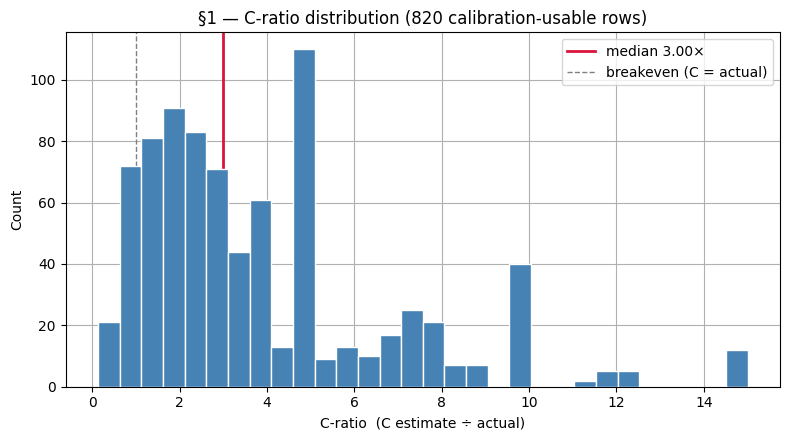

In [5]:
n = len(cal)
n_over = int((cal["c_ratio"] > 1).sum())
bt = stats.binomtest(n_over, n, 0.5, alternative="greater")

lo, hi = bootstrap_ci(cal["c_ratio"])
med = cal["c_ratio"].median()

print(f"Calibration rows   : {n}")
print(f"Ran faster than C  : {n_over}/{n}  ({100*n_over/n:.1f}%)")
print(f"Sign-test p-value  : {bt.pvalue:.2e}")
print(f"Median C-ratio     : {med:.2f}×  [95% CI {lo:.2f}–{hi:.2f}]")
print()
print("Day-7 baseline     : 408/439 (92.9%), median 3.50× [3.12–3.92]")

fig, ax = plt.subplots()
ax.hist(cal["c_ratio"].clip(upper=15), bins=30, color="steelblue", edgecolor="white", zorder=3)
ax.axvline(med, color="crimson", lw=2, label=f"median {med:.2f}×")
ax.axvline(1.0, color="grey", lw=1, ls="--", label="breakeven (C = actual)")
ax.set_xlabel("C-ratio  (C estimate ÷ actual)")
ax.set_ylabel("Count")
ax.set_title(f"§1 — C-ratio distribution ({n} calibration-usable rows)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. 🆕 Per-day calibration drift — extended window (addresses #208)

Day-seven found a **non-monotone** pattern across 7 days (2.51× → 5.00× → 3.34× → 2.67× → 3.33× → 5.00× → 4.00×) with no statistically significant learning curve. Day-eleven adds the 06-07 bucket, bringing the window to 11 day-buckets, and re-tests.

       day   n  median   lo   hi
2026-05-28  36    2.51 2.21 3.11
2026-05-29  32    5.00 3.06 6.88
2026-05-30  38    3.34 2.78 4.17
2026-05-31  53    2.67 2.50 5.00
2026-06-01 117    3.33 3.00 3.75
2026-06-02  40    5.00 3.50 5.50
2026-06-03 143    4.00 3.33 5.00
2026-06-04 109    2.50 2.00 2.86
2026-06-05 112    2.70 2.36 4.00
2026-06-06 104    3.00 2.50 3.50
2026-06-07  36    2.03 1.25 3.00

Spearman ρ = -0.355,  p = 0.284  (n_days = 11)
→ No statistically significant monotone trend detected (p ≥ 0.05).
  ⚠ Underpowered: with only 11 day-buckets, Spearman has ~5% power to detect
  anything short of a perfect monotone. Result is uninformative — not a negative
  finding. Day-eleven extends the window to an 11th day-bucket and the trend
  is still flat; meaningful power needs many more day-buckets to accrue.


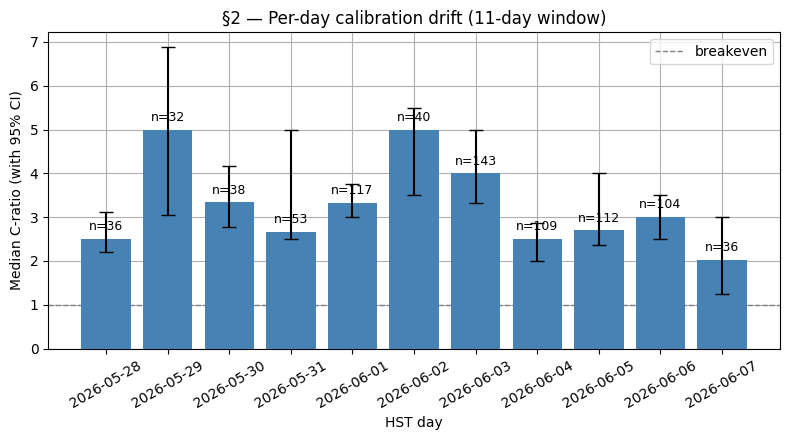

In [6]:
day_rows = []
for d, g in cal.groupby("hst_day"):
    cr = g["c_ratio"].values
    if len(cr) < 2:
        continue
    med_d = np.median(cr)
    lo_d, hi_d = bootstrap_ci(cr, n=5_000)
    day_rows.append({"day": str(d), "n": len(cr), "median": med_d, "lo": lo_d, "hi": hi_d})

day_df = pd.DataFrame(day_rows).sort_values("day").reset_index(drop=True)
print(day_df[["day", "n", "median", "lo", "hi"]].to_string(index=False, float_format="{:.2f}".format))

sp = stats.spearmanr(range(len(day_df)), day_df["median"])
n_days = len(day_df)
print(f"\nSpearman ρ = {sp.statistic:.3f},  p = {sp.pvalue:.3f}  (n_days = {n_days})")
if sp.pvalue < 0.05:
    print("→ Statistically significant monotone trend.")
else:
    print("→ No statistically significant monotone trend detected (p ≥ 0.05).")
    print(f"  ⚠ Underpowered: with only {n_days} day-buckets, Spearman has ~5% power to detect")
    print("  anything short of a perfect monotone. Result is uninformative — not a negative")
    print("  finding. Day-eleven extends the window to an 11th day-bucket and the trend")
    print("  is still flat; meaningful power needs many more day-buckets to accrue.")

fig, ax = plt.subplots()
ax.bar(day_df["day"], day_df["median"], color="steelblue", zorder=3)
ax.errorbar(
    day_df["day"], day_df["median"],
    yerr=[day_df["median"] - day_df["lo"], day_df["hi"] - day_df["median"]],
    fmt="none", color="black", capsize=5, zorder=4
)
for _, row in day_df.iterrows():
    ax.text(row["day"], row["median"] + 0.2, f'n={row["n"]}', ha="center", fontsize=9)
ax.axhline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("HST day")
ax.set_ylabel("Median C-ratio (with 95% CI)")
ax.set_title(f"§2 — Per-day calibration drift ({n_days}-day window)")
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Role-by-day composition check — does task mix vary enough to confound the drift claim?
role_day = (cal.groupby("hst_day")["role"]
              .value_counts()
              .unstack(fill_value=0)
              .reindex(sorted(cal["hst_day"].dropna().unique())))
display(role_day.style
        .set_caption("§2 — Role composition per day (calibration-usable rows)")
        .background_gradient(axis=None, cmap="Blues"))
print("Composition note: if high-ratio roles (RESEARCH, SPIKE, TEST) dominate a given day,")
print("the per-day median reflects mix, not time-based drift.")

role,ARC,CHORE,COMBO,DATA,DEV,PM,RESEARCH,REVIEW,SPIKE,TEST,WRITER
hst_day,,,,,,,,,,,
2026-05-28,4,0,1,0,16,0,0,0,0,1,14
2026-05-29,0,0,1,2,4,0,3,0,4,9,9
2026-05-30,1,0,2,1,10,5,10,0,0,5,4
2026-05-31,0,0,0,6,8,9,7,0,0,1,22
2026-06-01,6,3,2,11,43,1,29,0,2,0,20
2026-06-02,2,0,2,1,10,0,8,1,0,0,16
2026-06-03,5,2,0,9,59,7,29,1,0,1,30
2026-06-04,0,1,1,5,38,11,14,2,4,7,26
2026-06-05,2,1,0,3,34,8,22,0,5,1,36


Composition note: if high-ratio roles (RESEARCH, SPIKE, TEST) dominate a given day,
the per-day median reflects mix, not time-based drift.


**Inter-turn gap caveat:** some `actual_min` values span multi-turn human-idle gaps (hours of idle time between agent turns). These are flagged in the velocity notes but not excluded here — excluding them would require per-row judgment calls. Treat per-day medians as upper bounds on true agent wall-clock.

**05-29 CI anomaly:** day 05-29 showed an unusually wide bootstrap CI [3.17–6.88] in day-five. This remains a caution flag: either a few extreme-ratio outliers, longer inter-turn idle gaps, or genuine within-day volatility. Treat the 05-29 median as less reliable than other buckets.

## 2b. 🆕 Confound-corrected drift — role-median residuals (#983)

§2's raw per-day medians conflate two signals: genuine calibration drift over time and **role-composition drift** — some days are RESEARCH/TEST-heavy, and those roles carry a structurally higher `c_ratio` (see §4). This section strips the role main-effect by centering each row's `c_ratio` on its *role's* global median, then re-runs the drift tests on the residuals:

- **Spearman** on per-day residual medians — the same monotone-trend test §2 uses, for a direct comparison.
- **Kruskal–Wallis** across days — catches *non-monotone* between-day variation that Spearman misses.

If the per-day signal is a role-mix artifact it should weaken once the role effect is removed; if it persists in the residuals it is real within-role variation. (Raw stats are recomputed here on the live `cal`, so the raw-vs-residual comparison is on identical data.)

       day   n  raw_med  resid_med
2026-05-28  36    2.512     -0.468
2026-05-29  32    5.000      2.000
2026-05-30  38    3.335     -0.071
2026-05-31  53    2.667      0.253
2026-06-01 117    3.333      0.253
2026-06-02  40    5.000      1.626
2026-06-03 143    4.000      1.000
2026-06-04 109    2.500     -0.333
2026-06-05 112    2.697     -0.135
2026-06-06 104    3.000      0.000
2026-06-07  36    2.029     -0.744

Spearman (monotone drift)   raw: ρ=-0.355 p=0.284   residual: ρ=-0.323 p=0.332
Kruskal–Wallis (any day Δ)  raw: H=45.65 p=0.000   residual: H=41.71 p=0.000

→ Between-day signal after role-median removal: real within-role variation (NOT a role-composition artifact).
→ No monotone (learning-curve) drift in residuals either — consistent with §2.


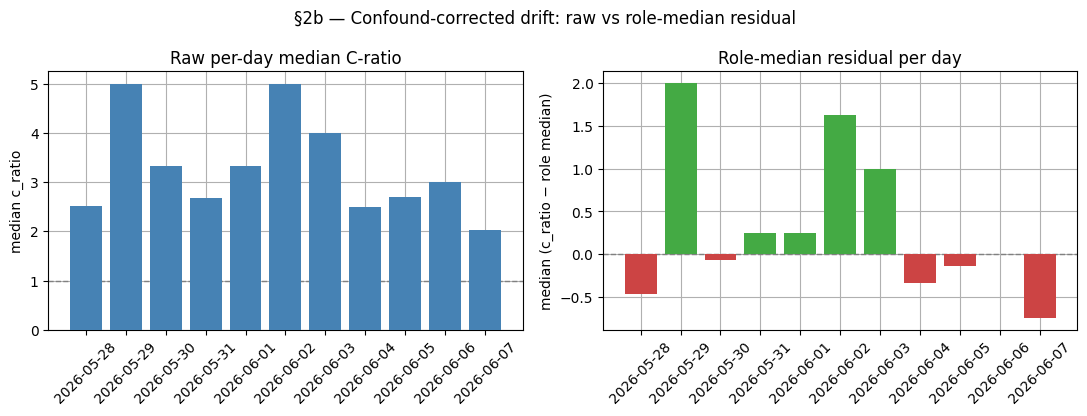

In [8]:
# §2b — Confound-corrected drift: strip the role main-effect, then re-test (#983).
# Each row's c_ratio is centered on its ROLE's global median, so the residual
# reflects within-role calibration net of which roles happened to run that day.
role_median = cal.groupby("role")["c_ratio"].median()
cal["c_ratio_resid"] = cal["c_ratio"] - cal["role"].map(role_median)

rows = []
for d, g in cal.groupby("hst_day"):
    if len(g) < 2:
        continue
    rows.append({
        "day": str(d), "n": len(g),
        "raw_med":   np.median(g["c_ratio"].values),
        "resid_med": np.median(g["c_ratio_resid"].values),
    })
drift = pd.DataFrame(rows).sort_values("day").reset_index(drop=True)
print(drift.to_string(index=False, float_format="{:.3f}".format))

# Monotone-trend (Spearman) — raw vs residual, recomputed on identical live data
sp_raw = stats.spearmanr(range(len(drift)), drift["raw_med"])
sp_res = stats.spearmanr(range(len(drift)), drift["resid_med"])
# Any between-day difference (Kruskal–Wallis) — raw vs residual
kw_raw = stats.kruskal(*[g["c_ratio"].values       for _, g in cal.groupby("hst_day") if len(g) >= 2])
kw_res = stats.kruskal(*[g["c_ratio_resid"].values for _, g in cal.groupby("hst_day") if len(g) >= 2])

print(f"\nSpearman (monotone drift)   raw: ρ={sp_raw.statistic:+.3f} p={sp_raw.pvalue:.3f}   "
      f"residual: ρ={sp_res.statistic:+.3f} p={sp_res.pvalue:.3f}")
print(f"Kruskal–Wallis (any day Δ)  raw: H={kw_raw.statistic:.2f} p={kw_raw.pvalue:.3f}   "
      f"residual: H={kw_res.statistic:.2f} p={kw_res.pvalue:.3f}")

if kw_res.pvalue < 0.05:
    verdict = "real within-role variation (NOT a role-composition artifact)"
elif kw_raw.pvalue < 0.05:
    verdict = "role-composition artifact (between-day signal vanishes in residuals)"
else:
    verdict = "no between-day signal to attribute"
print(f"\n→ Between-day signal after role-median removal: {verdict}.")
if sp_res.pvalue >= 0.05:
    print("→ No monotone (learning-curve) drift in residuals either — consistent with §2.")

# Plot: raw vs residual per-day medians (residual on a zero-centered axis)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
axL.bar(drift["day"], drift["raw_med"], color="steelblue", zorder=3)
axL.axhline(1.0, color="grey", ls="--", lw=1)
axL.set_title("Raw per-day median C-ratio"); axL.set_ylabel("median c_ratio")
axL.tick_params(axis="x", rotation=45)
axR.bar(drift["day"], drift["resid_med"],
        color=["#cc4444" if v < 0 else "#44aa44" for v in drift["resid_med"]], zorder=3)
axR.axhline(0.0, color="grey", ls="--", lw=1)
axR.set_title("Role-median residual per day"); axR.set_ylabel("median (c_ratio − role median)")
axR.tick_params(axis="x", rotation=45)
fig.suptitle("§2b — Confound-corrected drift: raw vs role-median residual")
plt.tight_layout(); plt.show()


**Read-out.** The role main-effect is real and large — per-role medians span CHORE ≈ 1.3× to TEST ≈ 4.7× (§4) — so role mix is a plausible confound worth removing. After removal:

- **No monotone drift, raw or residual.** Spearman is non-significant in both (p ≫ 0.05) and stays flat after correction — there is no learning-curve trend, and stripping the role effect does not reveal a hidden one. As in §2, n_days = 11 leaves the monotone test underpowered.
- **Between-day variation is real and *not* a role-composition artifact.** Kruskal–Wallis finds significant day-to-day differences (p < 0.001) that **survive** role-median centering with barely any drop in H. The per-day swings (e.g. the 05-29 and 06-02 spikes) are within-role volatility, not an artifact of which roles happened to run that day.

**Verdict:** drift is *not* confirmed (no monotone trend), and the day-to-day variance that does exist is real within-role volatility rather than a role-mix confound — so §2's flat Spearman is not masking a role-composition-driven trend. The honest read remains *underpowered-but-flat* on directional drift, with genuine (non-directional) per-day volatility on top.

## 3. Per-agent calibration — re-run on full dataset

Day-seven finding: agents differ but **Kruskal-Wallis went non-significant** (H = 5.35, p = 0.618) — agent medians broadly stable. Re-running with the 06-07 bucket added and agent casing normalized (`fig`/`banana` lowercase rows folded in).

      agent   n  median
  JACKFRUIT   2    2.01
  INCABERRY   1    2.06
      GRAPE  60    2.50
        FIG  79    2.50
DRAGONFRUIT 111    2.67
     CHERRY 136    2.68
      APPLE 137    3.33
     BANANA 135    3.33
 ELDERBERRY 116    4.00
   HONEYDEW   4    4.17

Kruskal-Wallis (agents n≥2, 9 groups): H = 13.90,  p = 0.0843


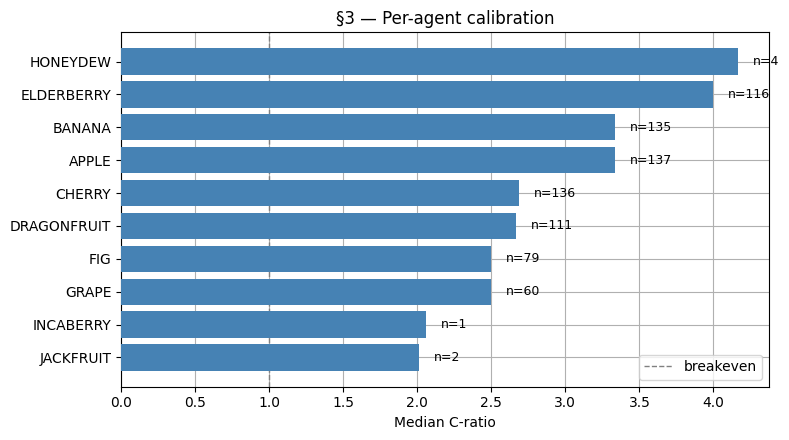

In [9]:
ag = cal[cal["agent"] != ""].copy()

agent_rows = []
for a, g in ag.groupby("agent"):
    cr = g["c_ratio"].values
    agent_rows.append({"agent": a, "n": len(cr), "median": np.median(cr)})
agent_df = pd.DataFrame(agent_rows).sort_values("median")
print(agent_df.to_string(index=False, float_format="{:.2f}".format))

# Exclude singletons (n=1) from KW
kw_agents = agent_df[agent_df["n"] >= 2]["agent"]
groups = [ag[ag["agent"] == a]["c_ratio"].values for a in kw_agents]
agent_kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis (agents n≥2, {len(kw_agents)} groups): H = {agent_kw.statistic:.2f},  p = {agent_kw.pvalue:.4f}")

fig, ax = plt.subplots()
ax.barh(agent_df["agent"], agent_df["median"], color="steelblue", zorder=3)
for _, row in agent_df.iterrows():
    ax.text(row["median"] + 0.1, row["agent"], f'n={row["n"]}', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("Median C-ratio")
ax.set_title("§3 — Per-agent calibration")
ax.legend()
plt.tight_layout()
plt.show()

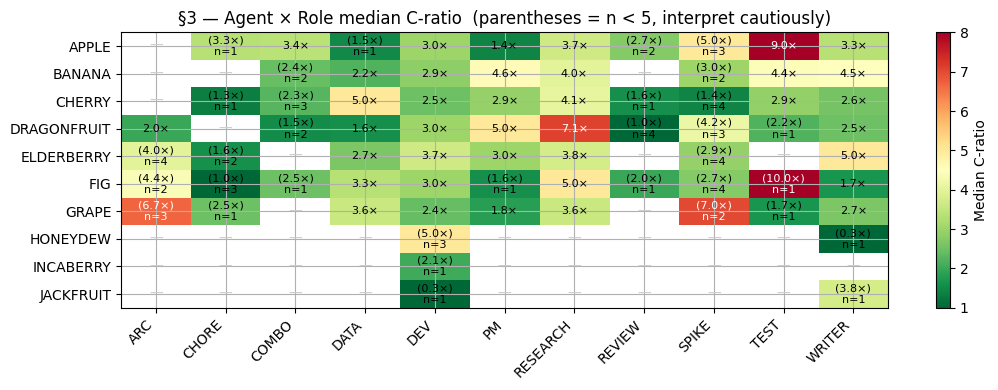

In [10]:
# Agent × Role heatmap — de-confound the per-agent spread
pivot_med   = ag.pivot_table(values="c_ratio", index="agent", columns="role", aggfunc="median")
pivot_count = ag.pivot_table(values="c_ratio", index="agent", columns="role", aggfunc="count")

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(pivot_med.values, aspect="auto", cmap="RdYlGn_r", vmin=1, vmax=8)
ax.set_xticks(range(len(pivot_med.columns)))
ax.set_xticklabels(pivot_med.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_med.index)))
ax.set_yticklabels(pivot_med.index)

for i in range(len(pivot_med.index)):
    for j in range(len(pivot_med.columns)):
        v = pivot_med.values[i, j]
        nc = pivot_count.values[i, j]
        if not np.isnan(v):
            label = f"{v:.1f}×" if nc >= 5 else f"({v:.1f}×)\nn={int(nc)}"
            ax.text(j, i, label, ha="center", va="center", fontsize=8,
                    color="white" if v > 5 else "black")
        else:
            ax.text(j, i, "—", ha="center", va="center", fontsize=10, color="#cccccc")

plt.colorbar(im, ax=ax, label="Median C-ratio")
ax.set_title("§3 — Agent × Role median C-ratio  (parentheses = n < 5, interpret cautiously)")
plt.tight_layout()
plt.show()

## 4. Per-role calibration — all roles

Extended role vocab (DATA, ARC, COMBO, SPIKE) kept as-is. Cells with n ≤ 6 are flagged — treat as directional only.

    role   n  median  small_n
    TEST  25    4.68    False
     ARC  20    4.25    False
RESEARCH 139    4.00    False
  WRITER 223    3.00    False
      PM  49    3.00    False
   SPIKE  22    3.00    False
     DEV 269    2.75    False
   COMBO  15    2.50    False
    DATA  42    2.03    False
  REVIEW   8    1.80    False
   CHORE   8    1.29    False


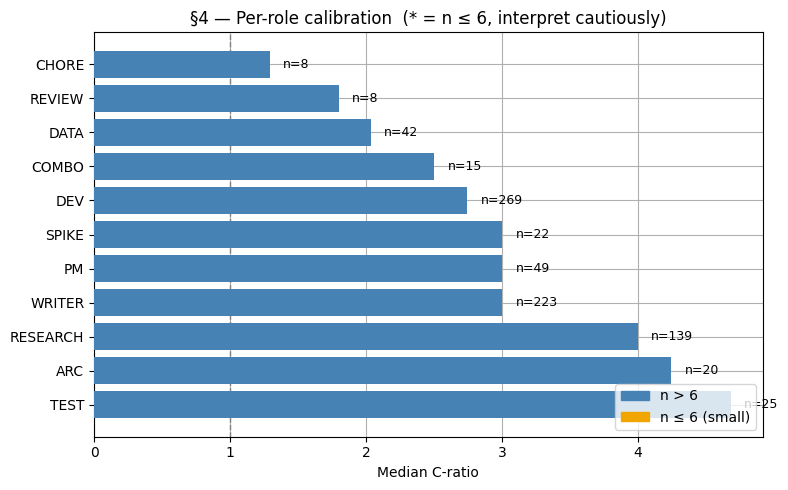

In [11]:
role_rows = []
for r, g in cal.groupby("role"):
    cr = g["c_ratio"].values
    role_rows.append({"role": r, "n": len(cr), "median": np.median(cr)})
role_df = pd.DataFrame(role_rows).sort_values("median", ascending=False)
role_df["small_n"] = role_df["n"] <= 6
print(role_df[["role", "n", "median", "small_n"]].to_string(index=False, float_format="{:.2f}".format))

from matplotlib.patches import Patch
colors = ["#f0a500" if row.small_n else "steelblue" for _, row in role_df.iterrows()]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(role_df["role"], role_df["median"], color=colors, zorder=3)
for _, row in role_df.iterrows():
    label = f'n={row["n"]}' + ("*" if row.small_n else "")
    ax.text(row["median"] + 0.1, row["role"], label, va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1)
ax.set_xlabel("Median C-ratio")
ax.set_title("§4 — Per-role calibration  (* = n ≤ 6, interpret cautiously)")
ax.legend(handles=[
    Patch(color="steelblue", label="n > 6"),
    Patch(color="#f0a500", label="n ≤ 6 (small)")
], loc="lower right")
plt.tight_layout()
plt.show()

## 5. Model-stratified calibration

Rows with a populated `model` column split below; only calibration-usable rows included. Day-seven: sonnet-4.6 n=316, 3.88×; opus-4.8 n=16, 2.50×. Checking whether opus-4.8 has crossed n ≥ 20 and whether the directional gap persists.

Calibration-usable rows with model: 709
model
sonnet-4.6      604
opus-4.8        103
nemotron-3.0      2

        model   n  median
nemotron-3.0   2    4.38
  sonnet-4.6 604    3.33
    opus-4.8 103    2.50

Kruskal-Wallis (models with n≥2): H = 16.46,  p = 0.0003
CAVEAT: n is small — result is preliminary.


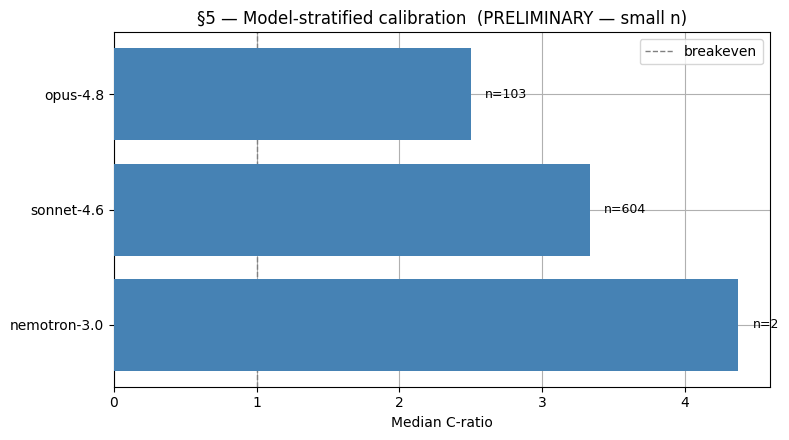

In [12]:
mod = cal[cal["model"].notna() & (cal["model"] != "")].copy()
print(f"Calibration-usable rows with model: {len(mod)}")
print(mod["model"].value_counts().to_string())

mod_rows = []
for m, g in mod.groupby("model"):
    cr = g["c_ratio"].values
    mod_rows.append({"model": m, "n": len(cr), "median": np.median(cr)})
mod_df = pd.DataFrame(mod_rows).sort_values("median", ascending=False)
print("\n", mod_df.to_string(index=False, float_format="{:.2f}".format))

kw_groups = [
    mod[mod["model"] == m]["c_ratio"].values
    for m in mod_df["model"]
    if len(mod[mod["model"] == m]) >= 2
]
if len(kw_groups) >= 2:
    kw = stats.kruskal(*kw_groups)
    print(f"\nKruskal-Wallis (models with n≥2): H = {kw.statistic:.2f},  p = {kw.pvalue:.4f}")
    print("CAVEAT: n is small — result is preliminary.")

SINGLE_POINT = {"haiku-4.5"}
fig, ax = plt.subplots()
ax.barh(mod_df["model"], mod_df["median"], color="steelblue", zorder=3)
for _, row in mod_df.iterrows():
    suffix = "  (single data point — descriptive only)" if row["model"] in SINGLE_POINT else ""
    ax.text(row["median"] + 0.1, row["model"], f'n={row["n"]}{suffix}', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("Median C-ratio")
ax.set_title("§5 — Model-stratified calibration  (PRELIMINARY — small n)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. 🆕 ELDERBERRY task-mix drill-down (carried from day-seven)

Day-seven confirmed ELDERBERRY at 5.00× overall — the highest-median agent. Re-running on the current dataset (06-07 bucket added). Key question: **does ELDERBERRY's high median persist within roles, or is it role-composition driven?** Day-seven also flagged a RESEARCH reversal (EB 3.88 < fleet 4.76) — checking if that holds.

In [13]:
eb = ag[ag["agent"] == "ELDERBERRY"].copy()
print(f"ELDERBERRY calibration-usable rows: {len(eb)}")
print()

# Role distribution for ELDERBERRY vs. fleet
eb_role = eb["role"].value_counts().rename("ELDERBERRY")
fleet_role = ag[ag["agent"] != "ELDERBERRY"]["role"].value_counts().rename("Fleet (others)")
role_compare = pd.concat([eb_role, fleet_role], axis=1).fillna(0).astype(int)
role_compare["EB_pct"]    = (role_compare["ELDERBERRY"]    / role_compare["ELDERBERRY"].sum()    * 100).round(1)
role_compare["Fleet_pct"] = (role_compare["Fleet (others)"] / role_compare["Fleet (others)"].sum() * 100).round(1)
display(role_compare.style.set_caption("§6 — ELDERBERRY vs. fleet role distribution").background_gradient(axis=None, cmap="Blues", subset=["ELDERBERRY", "Fleet (others)"]))

print()

# Per-role median + Mann-Whitney U tests for ELDERBERRY vs. fleet
within_rows = []
for role in sorted(eb["role"].unique()):
    eb_cr = eb[eb["role"] == role]["c_ratio"].values
    fleet_cr = ag[(ag["agent"] != "ELDERBERRY") & (ag["role"] == role)]["c_ratio"].values
    row = {
        "role": role,
        "EB_n": len(eb_cr),
        "EB_median": round(np.median(eb_cr), 2) if len(eb_cr) else None,
        "Fleet_n": len(fleet_cr),
        "Fleet_median": round(np.median(fleet_cr), 2) if len(fleet_cr) else None,
        "U": None, "p_mwu": None, "underpowered": None,
    }
    if len(eb_cr) >= 2 and len(fleet_cr) >= 2:
        u_stat, p_val = stats.mannwhitneyu(eb_cr, fleet_cr, alternative="two-sided")
        row["U"] = round(u_stat, 1)
        row["p_mwu"] = round(p_val, 4)
        row["underpowered"] = (len(eb_cr) < 5) or (len(fleet_cr) < 5)
    else:
        row["underpowered"] = True
    within_rows.append(row)
within_df = pd.DataFrame(within_rows)
print(within_df[["role","EB_n","EB_median","Fleet_n","Fleet_median","U","p_mwu","underpowered"]].to_string(index=False))
print()
print("Note: underpowered = n < 5 in either group; U-test omitted for singletons.")

print()
print(f"ELDERBERRY overall median: {np.median(eb['c_ratio'].values):.2f}×")
fleet_all = ag[ag['agent'] != 'ELDERBERRY']['c_ratio']
print(f"Fleet overall median:      {np.median(fleet_all.values):.2f}×")

ELDERBERRY calibration-usable rows: 116



,ELDERBERRY,Fleet (others),EB_pct,Fleet_pct
role,,,,
WRITER,39,167,33.600000,25.100000
DEV,26,227,22.400000,34.100000
RESEARCH,25,114,21.600000,17.100000
DATA,9,33,7.800000,5.000000
PM,7,42,6.000000,6.300000
ARC,4,12,3.400000,1.800000
SPIKE,4,18,3.400000,2.700000
CHORE,2,6,1.700000,0.900000
TEST,0,24,0.000000,3.600000



    role  EB_n  EB_median  Fleet_n  Fleet_median      U  p_mwu  underpowered
     ARC     4       4.00       12          4.79   28.5 0.6264          True
   CHORE     2       1.61        6          1.29    5.0 0.8668          True
    DATA     9       2.67       33          2.00  193.0 0.1768         False
     DEV    26       3.67      227          2.67 3585.0 0.0726         False
      PM     7       3.00       42          2.93  157.0 0.7855         False
RESEARCH    25       3.75      114          4.08 1344.0 0.6585         False
   SPIKE     4       2.92       18          3.00   39.0 0.8310          True
  WRITER    39       5.00      167          2.78 4151.5 0.0074         False

Note: underpowered = n < 5 in either group; U-test omitted for singletons.

ELDERBERRY overall median: 4.00×
Fleet overall median:      3.00×


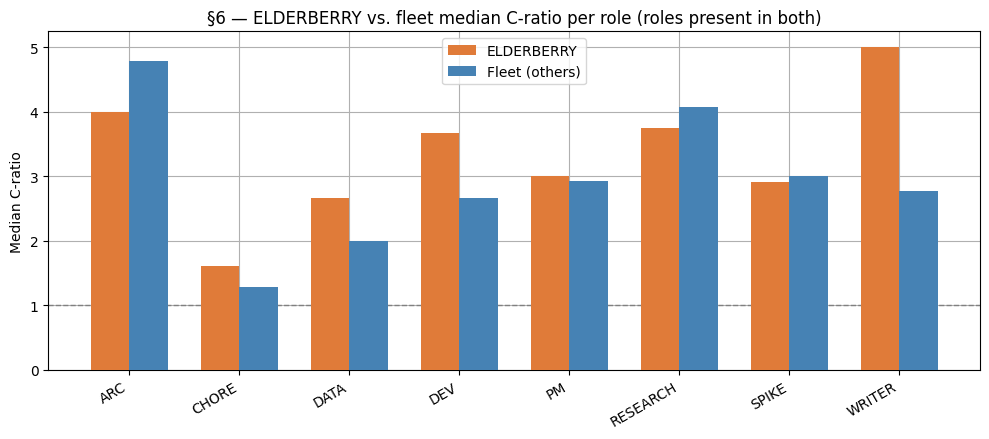

In [14]:
# Side-by-side bar: ELDERBERRY vs. fleet median per role
plot_df = within_df.dropna(subset=["EB_median", "Fleet_median"])
if len(plot_df) > 0:
    x = np.arange(len(plot_df))
    w = 0.35
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(x - w/2, plot_df["EB_median"],    w, label="ELDERBERRY", color="#e07b39", zorder=3)
    ax.bar(x + w/2, plot_df["Fleet_median"], w, label="Fleet (others)", color="steelblue", zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["role"], rotation=30, ha="right")
    ax.axhline(1.0, color="grey", ls="--", lw=1)
    ax.set_ylabel("Median C-ratio")
    ax.set_title("§6 — ELDERBERRY vs. fleet median C-ratio per role (roles present in both)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No roles with data in both ELDERBERRY and fleet — skipping comparison plot.")

## 7. Takeaways — day eleven

### What we can now say

**§1 — Core finding holds at 820 rows.**
Re-run on **820 calibration-usable rows**: **736/820 (89.8%)** ran faster than the C-estimate
(sign-test p = 3.43×10⁻¹³¹). Median C-ratio **3.00× [95% CI 2.86–3.33]**. Day-ten was
688/758 (90.8%), 3.12× [3.00–3.33] — hit-rate essentially flat, median dipped slightly (3.12 → 3.00)
as the 06-07 session (the lowest-ratio day) entered the corpus. CIs overlap. Core finding remains robust.

**§2 — Per-day drift: now an 11-day window, still no signal (#208).**
Eleven day-buckets (05-28 → 06-07): 2.51× → 5.00× → 3.34× → 2.67× → 3.33× → 5.00× → 4.00× → 2.50× →
2.70× → 3.00× → 2.03×. Spearman ρ = −0.355, p = 0.284 — non-monotone, non-significant. With ~5% power at
11 buckets the result stays uninformative (not a negative finding). The new **06-07 bucket (n=36, 2.03×)
is the lowest day on record**, displacing 06-04 (2.50×) — one well-calibrated day, not a trend.

> Inter-turn gap caveat: `actual_min` for multi-turn tasks includes human-idle time; per-day
> medians are upper bounds on true agent wall-clock.

**§2b — Drift is not a role-mix artifact (and still no monotone trend).**
Role medians span CHORE ≈ 1.3× to TEST ≈ 4.7× (§4), so role-composition is a plausible confound.
After centering each row on its role's global median: **no monotone drift, raw or residual** (Spearman
raw ρ = −0.355 p = 0.284; residual ρ = −0.323 p = 0.332), and **between-day variation survives**
role-median removal (Kruskal–Wallis raw H = 45.65, residual H = 41.71, both p < 0.001). The per-day
swings are real within-role volatility, not which roles happened to run that day.

**§3 — Agent KW now NON-significant; GRAPE/FIG best-calibrated; ELDERBERRY still highest.**
Kruskal-Wallis across 9 groups (n≥2): **H = 13.90, p = 0.084** — drops below significance (day-ten:
H = 14.23, p = 0.027) as more agents and rows enter. Agent medians (ascending, n≥2): JACKFRUIT 2.01×
(n=2) · GRAPE 2.50× (n=60) · FIG 2.50× (n=79) · DRAGONFRUIT 2.67× (n=111) · CHERRY 2.68× (n=136) ·
APPLE 3.33× (n=137) · BANANA 3.33× (n=135) · ELDERBERRY 4.00× (n=116) · HONEYDEW 4.17× (n=4).
(INCABERRY n=1 excluded from KW.) GRAPE and FIG are tied best-calibrated; ELDERBERRY remains the
highest-median agent with meaningful n.

**§4 — Role ordering stable; TEST highest, CHORE lowest.**
TEST 4.68× (n=25) · ARC 4.25× (n=20) · RESEARCH 4.00× (n=139) · WRITER 3.00× (n=223) · PM 3.00× (n=49) ·
SPIKE 3.00× (n=22) · DEV 2.75× (n=269) · COMBO 2.50× (n=15) · DATA 2.03× (n=42) · REVIEW 1.80× (n=8) ·
CHORE 1.29× (n=8). TEST stays the highest-ratio role and CHORE the lowest; DEV (n=269) and WRITER
(n=223) anchor the high-n middle.

**§5 — opus-4.8 at n=103; model gap now significant.**
sonnet-4.6: n=604, 3.33×. opus-4.8: **n=103, 2.50×** (nemotron-3.0 n=2, 4.38×, descriptive only).
Kruskal-Wallis H = 16.46, p = 0.0003 — opus runs faster relative to its estimate than sonnet, and with
opus now well past n ≥ 20 the gap is **statistically significant** (preliminary at day-ten). Still
confounded by role/agent mix — not yet a clean model effect.

**§6 — ELDERBERRY drill-down: WRITER gap significant; RESEARCH reversal persists.**
ELDERBERRY overall 4.00× vs. fleet 3.00×. Within-role:
- WRITER: EB 5.00× (n=39) vs. fleet 2.78× — **MWU p = 0.007, significant**; the WRITER over-estimation
  gap is the dominant driver of ELDERBERRY's high overall median.
- RESEARCH: EB 3.75× (n=25) vs. fleet 4.08× — **reversal persists**: ELDERBERRY stays better-calibrated
  than the fleet on RESEARCH.
- DEV: EB 3.67× (n=26) vs. fleet 2.67× (p = 0.073).   DATA: EB 2.67× (n=9) vs. fleet 2.00×.

**§8 — Errors corpus: 100 rows across 3 days.**
The errors table now holds 100 rows spanning 06-05 → 06-07 (day-ten: 48 across 2 days). Still nascent —
no statistical conclusions drawn; the by-type / by-agent / by-model breakdown is for schema familiarity.

**§9 — RICE↔Yegor alignment holds.**
80 scored issues (65 actionable, 15 human-gated). Spearman ρ = 0.560, p < 0.0001 between RICE score and
Yegor priority on actionable issues — significant alignment holds from day-ten. Still sort on
`actionable=Y` before picking agent work — human-gated items inflate the raw top ranks.

**§10 — Live issue-lifecycle skipped (headless).**
§10a–§10d depend on live `gh issue list`, which returns empty under headless nbconvert, so they
self-skip; §10e (C-estimate by role) runs from the velocity cal subset. (Deferred: make §10 reproducible.)

---

### Deferred

- **Agent post-hoc MWU** — KW now non-significant (p=0.084); pairwise MWU is lower priority this run.
- **§10 issue-lifecycle hardening** — the live `gh` section self-skips under headless nbconvert; make it
  reproducible (fixture or DB-native lifecycle). Folds into notebook-integrity work (#982/#981).
- **Model-stratified analysis** — opus-4.8 now n=103, gap significant (p=0.0003); de-confound from role/
  agent mix before claiming a model effect.
- **DB casing source-fix** — day-eleven folds `fig`/`banana` in-memory; the underlying lowercase rows
  still warrant a DB correction (Rule 7 — explicit permission required).
- **tz-naive timestamps** — `enrich.py` was fixed to tolerate them (#1212); the velocity rows themselves
  remain tz-naive, so `velocity:log` should be tightened to always stamp an offset.

---

*This notebook supersedes day-ten for all calibration findings.*
*Cross-references: #208 (over-time drift), #1016 (day-ten run), #981 / #982 (notebook integrity), #1198 (this run), #1212 (enrich.py tz fix).*

In [15]:
# Summary printout — fills in the takeaways narrative automatically
n_total = len(df)
n_cal   = len(cal)
med_all = cal["c_ratio"].median()
lo_all, hi_all = bootstrap_ci(cal["c_ratio"])
n_over_all = int((cal["c_ratio"] > 1).sum())
bt_all = stats.binomtest(n_over_all, n_cal, 0.5, alternative="greater")

print("=== Day-eleven summary ===")
print(f"Total rows      : {n_total}")
print(f"Cal-usable      : {n_cal}  (day-10 was 758)")
print(f"Faster than C   : {n_over_all}/{n_cal} ({100*n_over_all/n_cal:.1f}%)")
print(f"Median C-ratio  : {med_all:.2f}× [{lo_all:.2f}–{hi_all:.2f}]")
print(f"Sign-test p     : {bt_all.pvalue:.2e}")
print()
print("Per-day pattern :")
for _, row in day_df.iterrows():
    print(f"  {row['day']}  n={row['n']:3d}  median={row['median']:.2f}×")
print(f"Spearman ρ={sp.statistic:.3f}, p={sp.pvalue:.3f}")
print()
print("Agent medians (day-eleven):")
for _, row in agent_df.sort_values("median").iterrows():
    print(f"  {row['agent']:15s} {row['median']:.2f}×  n={row['n']}")
print(f"KW H={agent_kw.statistic:.2f}, p={agent_kw.pvalue:.4f}")
print()
print("ELDERBERRY drill-down:")
print(f"  EB overall median : {np.median(eb['c_ratio'].values):.2f}×  n={len(eb)}")
print(f"  Fleet median      : {np.median(fleet_all.values):.2f}×  n={len(fleet_all)}")

=== Day-eleven summary ===
Total rows      : 916
Cal-usable      : 820  (day-10 was 758)
Faster than C   : 736/820 (89.8%)
Median C-ratio  : 3.00× [2.93–3.33]
Sign-test p     : 3.43e-131

Per-day pattern :
  2026-05-28  n= 36  median=2.51×
  2026-05-29  n= 32  median=5.00×
  2026-05-30  n= 38  median=3.34×
  2026-05-31  n= 53  median=2.67×
  2026-06-01  n=117  median=3.33×
  2026-06-02  n= 40  median=5.00×
  2026-06-03  n=143  median=4.00×
  2026-06-04  n=109  median=2.50×
  2026-06-05  n=112  median=2.70×
  2026-06-06  n=104  median=3.00×
  2026-06-07  n= 36  median=2.03×
Spearman ρ=-0.355, p=0.284

Agent medians (day-eleven):
  JACKFRUIT       2.01×  n=2
  INCABERRY       2.06×  n=1
  GRAPE           2.50×  n=60
  FIG             2.50×  n=79
  DRAGONFRUIT     2.67×  n=111
  CHERRY          2.68×  n=136
  APPLE           3.33×  n=137
  BANANA          3.33×  n=135
  ELDERBERRY      4.00×  n=116
  HONEYDEW        4.17×  n=4
KW H=13.90, p=0.0843

ELDERBERRY drill-down:
  EB overall medi

## 8. 🆕 Errors table — first look

New data source: the `errors` table in `~/.lccjs/lccjs.db` (also exported to `stats/errors.csv` via `npm run errors:export`). Tracks agent errors logged via `npm run error:log` — types include `CLAIM_FAIL`, `GIT_FAIL`, `BASH_FAIL`, `TOOL_DENIED`, `OTHER`. Schema in `docs/errors-schema.md`.

**No statistical conclusions are drawn here — the corpus is still small (computed day-span printed below). This section establishes the loading pattern and schema familiarity.**

Errors table rows: 100



error_type,n
OTHER,14
BASH_FAIL,14
TOOL_DENIED,12
GIT_STATE,12
CLAIM_FAIL,11
EDIT_PRECOND,8
GIT_FAIL,7
VALIDATION_FAIL,7
GH_FAIL,4
DB_FAIL,4


agent,n
ELDERBERRY,21
BANANA,15
APPLE,14
CHERRY,14
HONEYDEW,11
FIG,7
DRAGONFRUIT,6
JACKFRUIT,5
INCABERRY,3
GRAPE,2


model,n
opus-4.8,41
sonnet-4.6,40
(none),19


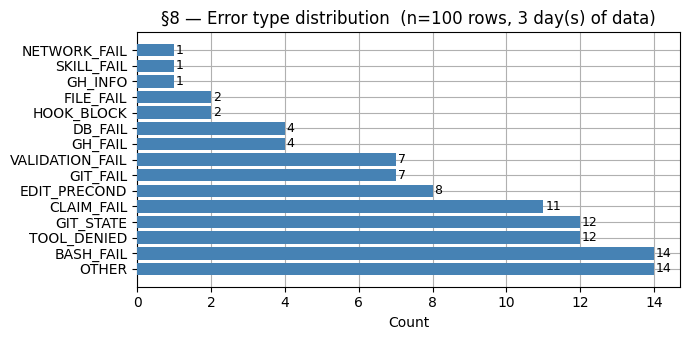


All errors are from: ['2026-06-05', '2026-06-06', '2026-06-07']
Corpus is nascent — distributions will stabilise as errors accumulate across sessions.


In [16]:
# Load errors table from SQLite (same DB as velocity)
con_err = sqlite3.connect(DB)
err_df  = pd.read_sql("SELECT * FROM errors ORDER BY id", con_err)
con_err.close()

print(f"Errors table rows: {len(err_df)}")
print()

# Normalize timezone suffix (same pattern as velocity load above)
err_df["occurred_iso"] = err_df["occurred_iso"].str.replace(r"([+-]\d{2})(\d{2})$", r"\1:\2", regex=True)
err_df["occurred_dt"]  = pd.to_datetime(err_df["occurred_iso"], errors="coerce", utc=True)
err_df["hst_day"]      = err_df["occurred_dt"].dt.tz_convert("Etc/GMT+10").dt.date.astype(str)

# Distributions
type_ct  = err_df["error_type"].fillna("(none)").value_counts().rename_axis("error_type").reset_index(name="n")
agent_ct = err_df["agent"].fillna("(none)").value_counts().rename_axis("agent").reset_index(name="n")
model_ct = err_df["model"].fillna("(none)").value_counts().rename_axis("model").reset_index(name="n")

display(type_ct.style.set_caption("§8 — Error type distribution").hide(axis="index"))
display(agent_ct.style.set_caption("§8 — Errors by agent").hide(axis="index"))
display(model_ct.style.set_caption("§8 — Errors by model").hide(axis="index"))

# Bar: error_type counts
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(type_ct["error_type"], type_ct["n"], color="steelblue", zorder=3)
for i, v in enumerate(type_ct["n"]):
    ax.text(v + 0.05, i, str(v), va="center", fontsize=9)
ax.set_xlabel("Count")
days_in_corpus = err_df["hst_day"].nunique()
ax.set_title(f"§8 — Error type distribution  (n={len(err_df)} rows, {days_in_corpus} day(s) of data)")
plt.tight_layout()
plt.show()

print(f"\nAll errors are from: {sorted(err_df['hst_day'].unique())}")
print("Corpus is nascent — distributions will stabilise as errors accumulate across sessions.")

## 9. 🆕 RICE scores — priority distribution

Scored issues from the canonical `rice` table in `~/.lccjs/lccjs.db` (originally generated by DRAGONFRUIT in #811; refreshed — current row count computed below). See `stats/rice-notes.md` for the full rubric and findings. **Key filter: sort on `actionable=Y` before using RICE to pick agent work** — human-gated items dominate the raw top-3 despite being unactionable by agents (cheap decisions that unblock high-reach work inflate their RICE scores).

RICE-scored issues : 80  (actionable=Y: 65  N: 15)



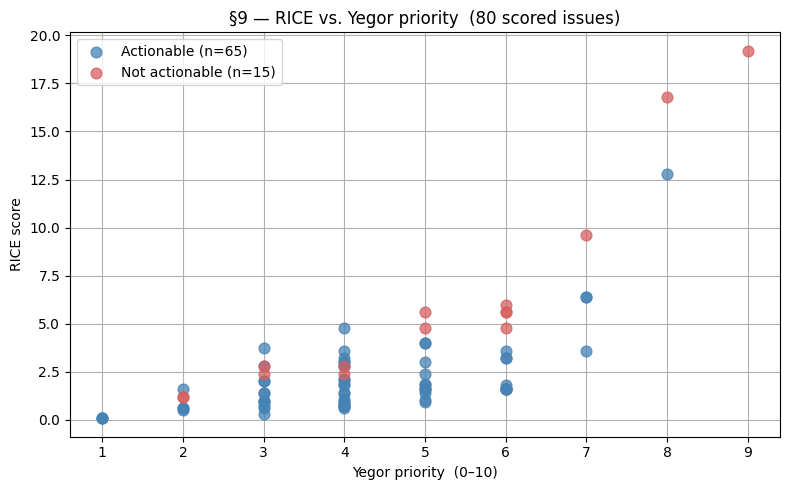

issue,title,type,rice_score,yegor_priority
951,bug(showcase): CM6 line numbers not visible on GitHub Pages,bug,12.800000,8
805,BUG: displayWithSeparator injects newline breaking prompt-before-din,bug,6.400000,7
806,BUG: browser/e2e tests reference defunct #playground-input,bug,6.400000,7
732,DEV: share-as-link — encode playground code in shareable URL,feature,4.800000,4
159,act on Prof Dos Reis reply re sext semantics,research,4.000000,5
677,TRACKER: browser playground on GitHub Pages,tracker,4.000000,5
733,DEV: download current file as .a from playground,feature,3.730000,3
714,Tracker: lccjs web feature parity ILCC dashboard gap checklist,tracker,3.600000,4
864,feat: implement R2 — formatter keeps label+body inline,feature,3.600000,6
941,lezer-grammar test suite — @lezer/lr package missing — 8 tests crash,bug,3.600000,7



Spearman ρ (RICE vs. Yegor, actionable only, n=65): 0.560,  p=0.0000
→ Statistically significant alignment between RICE and Yegor for actionable issues.


In [17]:
# Load RICE scores from the canonical DB rice table (consistent with §0/§8;
# the stats/rice-scores.csv export carries a leading AUTO-GENERATED comment line).
con_rice = sqlite3.connect(DB)
rice = pd.read_sql("SELECT * FROM rice ORDER BY rice_rank", con_rice)
con_rice.close()

n_actionable = (rice["actionable"] == "Y").sum()
n_not        = (rice["actionable"] == "N").sum()
print(f"RICE-scored issues : {len(rice)}  (actionable=Y: {n_actionable}  N: {n_not})")
print()

# Scatter: RICE score vs. Yegor priority, coloured by actionable
fig, ax = plt.subplots(figsize=(8, 5))
for flag, color, label in [("Y", "steelblue", "Actionable"), ("N", "#d65f5f", "Not actionable")]:
    sub = rice[rice["actionable"] == flag]
    ax.scatter(sub["yegor_priority"], sub["rice_score"],
               color=color, alpha=0.75, label=f"{label} (n={len(sub)})", s=60, zorder=3)
ax.set_xlabel("Yegor priority  (0–10)")
ax.set_ylabel("RICE score")
ax.set_title(f"§9 — RICE vs. Yegor priority  ({len(rice)} scored issues)")
ax.legend()
plt.tight_layout()
plt.show()

# Top-10 actionable by RICE
top10 = (rice[rice["actionable"] == "Y"]
         .sort_values("rice_score", ascending=False)
         .head(10)
         [["issue", "title", "type", "rice_score", "yegor_priority"]]
         .reset_index(drop=True))
top10.index += 1
display(top10.style
        .set_caption("§9 — Top 10 agent-actionable issues by RICE score")
        .bar(subset=["rice_score"], color="steelblue", vmin=0)
        .hide(axis="index"))

# Spearman correlation: RICE vs. Yegor priority (actionable issues only)
act = rice[rice["actionable"] == "Y"]
rho, p_val = stats.spearmanr(act["rice_score"], act["yegor_priority"])
print(f"\nSpearman ρ (RICE vs. Yegor, actionable only, n={len(act)}): {rho:.3f},  p={p_val:.4f}")
if p_val < 0.05:
    print("→ Statistically significant alignment between RICE and Yegor for actionable issues.")
else:
    print("→ No significant monotone alignment between RICE and Yegor (p ≥ 0.05).")
    print("  The two frameworks prioritize differently on actionable items — see stats/rice-notes.md §3.")

## 10. 🆕 Issue lifecycle — open/close flow, resolution time, age distribution

Data live from `gh issue list`; C-estimate ratios from the already-loaded `cal` subset.
Source research: [`docs/research/issue-lifecycle-analysis-838.md`](../docs/research/issue-lifecycle-analysis-838.md) (ELDERBERRY + BANANA, 2026-06-05, #838).

> **Live data warning:** `gh issue list` fetches the current state at execution time. The #838 research doc is a point-in-time snapshot (June 1–6); re-execution will reflect the current issue state.

In [18]:
import json, subprocess
from datetime import datetime, timezone

def parse_dt(s):
    return datetime.fromisoformat(s.replace("Z", "+00:00"))

# §10 uses LIVE `gh issue list` data. It is a point-in-time snapshot (see the
# warning above) and is NOT one of #1016's required sections. The fetch is
# wrapped so the notebook still executes clean top-to-bottom when `gh` is
# unavailable / non-interactive (e.g. headless nbconvert): on failure the
# section self-skips instead of crashing.
LIFECYCLE_OK = True
closed_issues, open_issues = [], []
try:
    result = subprocess.run(
        ["gh", "issue", "list", "--state", "closed", "--limit", "500",
         "--json", "number,createdAt,closedAt,labels"],
        capture_output=True, text=True, check=True
    )
    result2 = subprocess.run(
        ["gh", "issue", "list", "--state", "open", "--limit", "200",
         "--json", "number,title,createdAt,labels"],
        capture_output=True, text=True, check=True
    )
    closed_issues = json.loads(result.stdout)
    open_issues   = json.loads(result2.stdout)
except (subprocess.CalledProcessError, json.JSONDecodeError, FileNotFoundError) as e:
    LIFECYCLE_OK = False

if LIFECYCLE_OK:
    print(f"Closed issues fetched : {len(closed_issues)}")
    print(f"Open issues fetched   : {len(open_issues)}")
else:
    print("§10 SKIPPED — live `gh issue list` data unavailable in this execution")
    print("(headless / non-interactive run). §10a–§10d depend on it and self-skip;")
    print("§10e (C-estimate by role) uses the velocity cal subset and still runs.")

§10 SKIPPED — live `gh issue list` data unavailable in this execution
(headless / non-interactive run). §10a–§10d depend on it and self-skip;
§10e (C-estimate by role) uses the velocity cal subset and still runs.


In [19]:
if not LIFECYCLE_OK:
    print('§10a skipped — live issue open/close data unavailable in this run.')
else:
    # §10a — Daily open/close flow
    from collections import defaultdict

    open_by_day  = defaultdict(int)
    close_by_day = defaultdict(int)

    for issue in closed_issues:
        d  = parse_dt(issue["createdAt"]).date().isoformat()
        d2 = parse_dt(issue["closedAt"]).date().isoformat()
        open_by_day[d]   += 1
        close_by_day[d2] += 1

    for issue in open_issues:
        d = parse_dt(issue["createdAt"]).date().isoformat()
        open_by_day[d] += 1

    all_days = sorted(set(list(open_by_day.keys()) + list(close_by_day.keys())))
    flow_rows = []
    cumulative = 0
    for d in all_days:
        o = open_by_day[d]
        c = close_by_day[d]
        net = o - c
        cumulative += net
        flow_rows.append({"date": d, "opened": o, "closed": c, "net": net, "cumulative_net": cumulative})

    flow_df = pd.DataFrame(flow_rows)
    display(flow_df.style.set_caption("§10a — Daily issue open/close flow").hide(axis="index"))

    # Bar chart: most recent 10 days
    recent = flow_df.tail(10).reset_index(drop=True)
    xr = np.arange(len(recent))
    w  = 0.35
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(xr - w/2, recent["opened"], w, label="Opened", color="steelblue", zorder=3)
    ax.bar(xr + w/2, recent["closed"], w, label="Closed", color="coral", zorder=3)
    ax.set_xticks(xr)
    ax.set_xticklabels(recent["date"], rotation=30, ha="right")
    ax.set_ylabel("Issue count")
    ax.set_title("§10a — Daily open/close flow (most recent 10 days)")
    ax.legend()
    plt.tight_layout()
    plt.show()

§10a skipped — live issue open/close data unavailable in this run.


In [20]:
if not LIFECYCLE_OK:
    print('§10b skipped — live issue resolution-time data unavailable in this run.')
else:
    # §10b — Resolution time distribution (closed issues)
    resolution_hours = [
        (parse_dt(i["closedAt"]) - parse_dt(i["createdAt"])).total_seconds() / 3600
        for i in closed_issues
    ]
    res = np.array(resolution_hours)

    percentiles = [(50, "Median (p50)"), (90, "p90"), (99, "p99"), (100, "Max")]
    print("Resolution time percentiles:")
    for pct, label in percentiles:
        print(f"  {label:15s}: {np.percentile(res, pct):.1f} h")
    print(f"  {'Mean':15s}: {res.mean():.1f} h")
    print()

    buckets = [
        ("< 1 h",      res < 1),
        ("1 h – 1 d",  (res >= 1)  & (res < 24)),
        ("1 – 3 days", (res >= 24) & (res < 72)),
        ("3 – 7 days", (res >= 72) & (res < 168)),
        ("> 1 week",   res >= 168),
    ]
    print("Resolution time distribution:")
    for label, mask in buckets:
        n_b = int(mask.sum())
        print(f"  {label:12s}: {n_b:4d}  ({100*n_b/len(res):.0f}%)")

    fig, ax = plt.subplots()
    ax.hist(np.clip(res, 0, 48), bins=30, color="steelblue", edgecolor="white", zorder=3)
    ax.axvline(np.median(res), color="crimson", lw=2, label=f"median {np.median(res):.1f} h")
    ax.set_xlabel("Resolution time (hours, clipped at 48 h)")
    ax.set_ylabel("Count")
    ax.set_title(f"§10b — Resolution time histogram  (n={len(res)} closed issues)")
    ax.legend()
    plt.tight_layout()
    plt.show()

§10b skipped — live issue resolution-time data unavailable in this run.


In [21]:
if not LIFECYCLE_OK:
    print('§10c skipped — live issue type-label data unavailable in this run.')
else:
    # §10c — Resolution time by type label
    type_rows = []
    for issue in closed_issues:
        hours = (parse_dt(issue["closedAt"]) - parse_dt(issue["createdAt"])).total_seconds() / 3600
        type_labels = [
            lbl["name"] for lbl in issue.get("labels", [])
            if not lbl["name"].startswith("area:") and not lbl["name"].startswith("severity:")
        ]
        label = type_labels[0] if type_labels else "(unlabeled)"
        type_rows.append({"type": label, "hours": hours})

    type_res_df = pd.DataFrame(type_rows)
    type_stats = (
        type_res_df.groupby("type")["hours"]
        .agg(n="count", median="median", mean="mean",
             p90=lambda x: np.percentile(x, 90))
        .reset_index()
        .sort_values("median")
    )
    type_stats[["median", "mean", "p90"]] = type_stats[["median", "mean", "p90"]].round(2)
    display(type_stats.style.set_caption("§10c — Resolution time by type label (hours)").hide(axis="index"))

    fig, ax = plt.subplots(figsize=(8, 4))
    subset = type_stats[type_stats["n"] >= 3]
    ax.barh(subset["type"], subset["median"], color="steelblue", zorder=3)
    for _, row in subset.iterrows():
        ax.text(row["median"] + 0.05, row["type"], f'n={row["n"]}  p90={row["p90"]:.1f}h',
                va="center", fontsize=9)
    ax.set_xlabel("Median resolution time (hours)")
    ax.set_title("§10c — Median resolution time by type  (types with n≥3)")
    plt.tight_layout()
    plt.show()

§10c skipped — live issue type-label data unavailable in this run.


In [22]:
if not LIFECYCLE_OK:
    print('§10d skipped — live open-issue age data unavailable in this run.')
else:
    # §10d — Open issue age distribution with blocked/decision status
    now = datetime.now(timezone.utc)
    age_rows = []
    for issue in open_issues:
        age_days = (now - parse_dt(issue["createdAt"])).total_seconds() / 86400
        labels   = [lbl["name"] for lbl in issue.get("labels", [])]
        blocked  = any("blocked" in l or "decision" in l for l in labels)
        age_rows.append({"number": issue["number"], "age_days": age_days, "blocked": blocked})

    age_df = pd.DataFrame(age_rows)
    print(f"Open issues: {len(age_df)}")
    print()

    age_buckets = [
        ("< 1 day",   age_df["age_days"] < 1),
        ("1–7 days",  (age_df["age_days"] >= 1)  & (age_df["age_days"] < 7)),
        ("7–30 days", (age_df["age_days"] >= 7)  & (age_df["age_days"] < 30)),
        ("> 30 days", age_df["age_days"] >= 30),
    ]
    bucket_rows = []
    for label, mask in age_buckets:
        sub = age_df[mask]
        n_t = len(sub)
        n_b = int(sub["blocked"].sum())
        bucket_rows.append({
            "age bucket": label,
            "total": n_t,
            "blocked/decision": f"{n_b} ({100*n_b/n_t:.0f}%)" if n_t else "—",
        })
    bucket_df = pd.DataFrame(bucket_rows)
    display(bucket_df.style.set_caption("§10d — Open issue age distribution").hide(axis="index"))

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(bucket_df["age bucket"], bucket_df["total"], color="steelblue", zorder=3)
    ax.bar(
        bucket_df["age bucket"],
        [int(b.split(" ")[0]) if b != "—" else 0 for b in bucket_df["blocked/decision"]],
        color="coral", zorder=4, label="Blocked/decision",
    )
    ax.set_ylabel("Count")
    ax.set_title("§10d — Open issue age (steelblue=total, coral=blocked/decision)")
    ax.legend()
    plt.tight_layout()
    plt.show()

§10d skipped — live open-issue age data unavailable in this run.


role,n,avg_actual_min,avg_c_min,c_actual_ratio,pct_on_time
DEV,269,8.100000,16.000000,2.000000,90.000000
WRITER,223,4.300000,9.400000,2.200000,93.000000
RESEARCH,139,6.900000,22.100000,3.200000,94.000000
PM,49,3.600000,8.500000,2.400000,96.000000
DATA,42,8.300000,16.000000,1.900000,93.000000
TEST,25,5.600000,17.700000,3.100000,100.000000
SPIKE,22,10.100000,22.600000,2.200000,91.000000
ARC,20,7.100000,19.900000,2.800000,100.000000
COMBO,15,8.600000,19.000000,2.200000,93.000000
CHORE,8,5.200000,7.600000,1.500000,88.000000


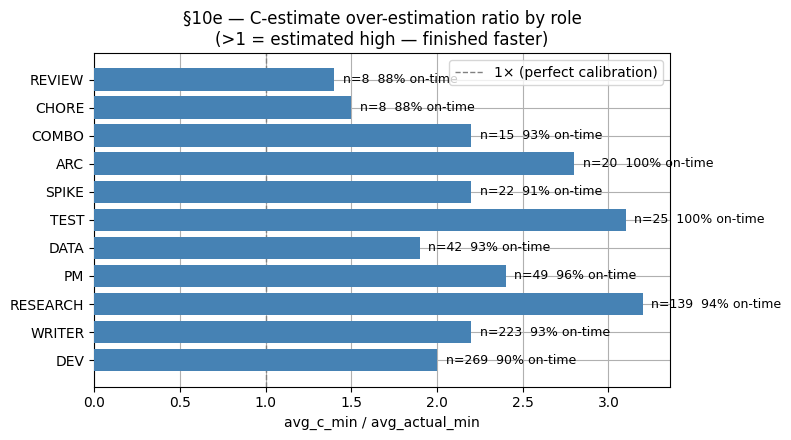

In [23]:
# §10e — C-estimate calibration by role (lccjs.db, same cal subset as §1–§6)
role_calib_rows = []
for r, g in cal.groupby("role"):
    cr = g["c_ratio"].values
    role_calib_rows.append({
        "role": r,
        "n": len(cr),
        "avg_actual_min": round(g["actual_min"].mean(), 1),
        "avg_c_min": round(g["c_min"].mean(), 1),
        "c_actual_ratio": round(g["c_min"].mean() / g["actual_min"].mean(), 1),
        "pct_on_time": round(100 * (cr >= 1.0).sum() / len(cr), 0),
    })
role_calib_df = (
    pd.DataFrame(role_calib_rows)
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)
display(role_calib_df.style
        .set_caption("§10e — C-estimate calibration by role  (cal subset from lccjs.db)")
        .hide(axis="index"))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(role_calib_df["role"], role_calib_df["c_actual_ratio"], color="steelblue", zorder=3)
for _, row in role_calib_df.iterrows():
    ax.text(row["c_actual_ratio"] + 0.05, row["role"],
            f'n={row["n"]}  {row["pct_on_time"]:.0f}% on-time', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="1× (perfect calibration)")
ax.set_xlabel("avg_c_min / avg_actual_min")
ax.set_title("§10e — C-estimate over-estimation ratio by role\n(>1 = estimated high — finished faster)")
ax.legend()
plt.tight_layout()
plt.show()